# Compute exposure pixel table

In [3]:
from wtlike import *

# check_data(update=True)

In [ ]:
from like3.exposure import (
    EffectiveAreaIRF,
    ExposureMap,
    make_aeff_costheta_function,
    make_exposure_map_healpix,
    build_pixel_table_exposure,
)


In [40]:
# Import livetime utilities from the workspace-local like3.livetime module.
import importlib.util
import sys
from pathlib import Path

module_path = Path('/home/burnett/work/pixel-table/like3/livetime.py')
if not module_path.exists():
    raise FileNotFoundError(f'Could not find {module_path}')
spec = importlib.util.spec_from_file_location('like3.livetime', module_path)
if spec is None or spec.loader is None:
    raise RuntimeError(f'Could not load module spec for {module_path}')
mod = importlib.util.module_from_spec(spec)
sys.modules['like3.livetime'] = mod
spec.loader.exec_module(mod)
build_livetime_map = mod.build_livetime_map
read_livetime_map = mod.read_livetime_map
write_healpix_map = mod.write_healpix_map
zenith_angle_map_from_sc = mod.zenith_angle_map_from_sc

In [41]:
# Build and save the full GTI-filtered livetime map using the workspace-local like3.livetime module.
import importlib.util
import sys
from pathlib import Path

module_path = Path('/home/burnett/work/pixel-table/like3/livetime.py')
if not module_path.exists():
    raise FileNotFoundError(f'Could not find {module_path}')
spec = importlib.util.spec_from_file_location('like3.livetime', module_path)
if spec is None or spec.loader is None:
    raise RuntimeError(f'Could not load module spec for {module_path}')
mod = importlib.util.module_from_spec(spec)
sys.modules['like3.livetime'] = mod
spec.loader.exec_module(mod)
build_livetime_map = mod.build_livetime_map

cfg = Config()
nside_all = 64

res = build_livetime_map(
    config=cfg,
    nside=nside_all,
    extra_gti_files=('nogrb.gti', 'nosolarflares.gti'),
    output_dir='files',
    save=True,
    overwrite=True,
    mjd_range=None,
 )

ltmap_all = res['livetime_map']
npy_file = res.get('npy_file')
fits_file = res.get('fits_file')
combined_exclusions = res['combined_exclusions']

print(f"weeks processed: {res['weeks_processed']}")
print(f"combined exclusions: {len(combined_exclusions) // 2}")
print(f"nside={res['nside']}, npix={res['npix']}")
print(f"total livetime (GTI-filtered): {res['total_livetime']:,.1f} s")
if npy_file is not None:
    print(f'saved: {npy_file}')
if fits_file is not None:
    print(f'saved: {fits_file}')

weeks processed: 921
combined exclusions: 97448
nside=64, npix=49152
total livetime (GTI-filtered): 423,445,728.0 s
saved: files/livetime_allweeks_gti_nside64.npy
saved: files/livetime_allweeks_gti_nside64.fits


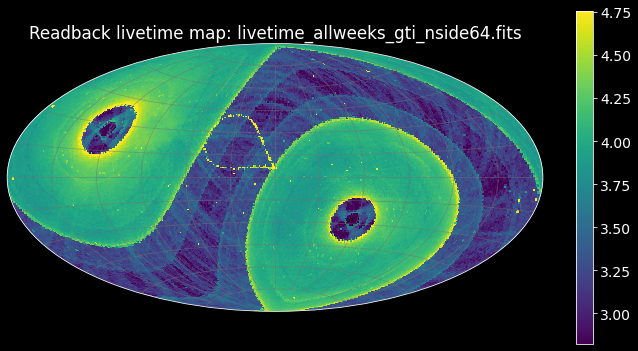

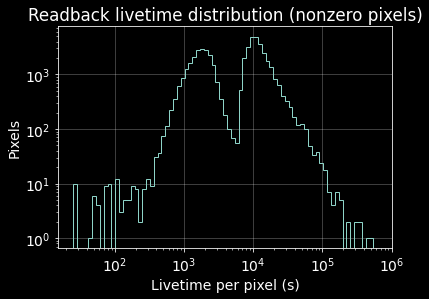

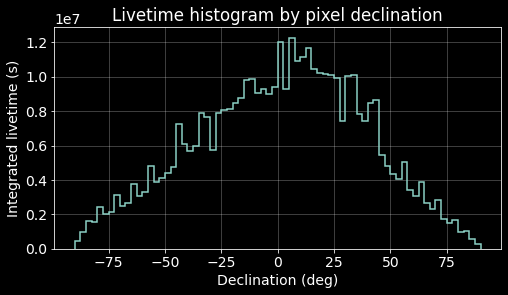

Loaded: files/livetime_allweeks_gti_nside64.fits
npix=49,152, nonzero=49,143
total livetime: 423,445,728.0 s


In [ ]:
from pathlib import Path

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import Galactic
from astropy_healpix import HEALPix, npix_to_nside
from utilities.skymaps import AITfigure

# Read back the saved all-weeks livetime map and plot it.
livetime_path = Path('files/livetime_allweeks_gti_nside64.fits')
if not livetime_path.exists():
    raise FileNotFoundError(f'Could not find {livetime_path}')

ltmap_saved = read_livetime_map(livetime_path, dtype=np.float32)

# AITfigure does not provide built-in log normalization, so plot log10(values).
pos = ltmap_saved > 0
plot_log_lt = np.full_like(ltmap_saved, np.nan, dtype=np.float32)
plot_log_lt[pos] = np.log10(ltmap_saved[pos])

with plt.style.context('dark_background'):
    fig = AITfigure(figsize=(12, 6), grid_color='0.45')
    fig.healpix_fill(
        plot_log_lt,
        pixelsize=1.0,
        colorbar=True,
        cb_kw={'label': 'log10 livetime (s)'},
        cmap='viridis',
        vmin=float(np.nanpercentile(plot_log_lt, 1)),
        vmax=float(np.nanpercentile(plot_log_lt, 99.5)),
    )
    fig.title(f'Readback livetime map: {livetime_path.name}')
    fig.show()

    vals = ltmap_saved[ltmap_saved > 0]
    plt.figure(figsize=(6, 4))
    plt.hist(vals, bins=np.logspace(np.log10(vals.min()), np.log10(vals.max()), 80), histtype='step', log=True)
    plt.gca().set_xscale('log')
    plt.xlabel('Livetime per pixel (s)')
    plt.ylabel('Pixels')
    plt.title('Readback livetime distribution (nonzero pixels)')
    plt.grid(alpha=0.3)
    plt.show()

    # Livetime histogram binned by pixel latitude in the map frame.
    npix = ltmap_saved.size
    nside_saved = int(npix_to_nside(npix))
    pix = np.arange(npix)
    hpix_saved = HEALPix(nside=nside_saved, order='ring', frame=Galactic())
    _, lat = hpix_saved.healpix_to_lonlat(pix)
    declination = lat.to_value(u.deg)
    dec_bins = np.linspace(-90, 90, 73)  # 2.5-degree bins

    plt.figure(figsize=(8, 4))
    plt.hist(declination, bins=dec_bins, weights=ltmap_saved, histtype='step', linewidth=1.5)
    plt.xlabel('Declination (deg)')
    plt.ylabel('Integrated livetime (s)')
    plt.title('Livetime histogram by pixel declination')
    plt.grid(alpha=0.3)
    plt.show()

print(f'Loaded: {livetime_path}')
print(f'npix={ltmap_saved.size:,}, nonzero={(ltmap_saved > 0).sum():,}')
print(f'total livetime: {ltmap_saved.sum():,.1f} s')

In [ ]:
from importlib import reload
import like3.exposure as exposure_mod; reload(exposure_mod)
make_exposure_map_healpix = exposure_mod.make_exposure_map_healpix

from like3.likelihood import Likelihood

import inspect
print(f'make_exposure_map_healpix signature: {inspect.signature(make_exposure_map_healpix)}')


loaded: /home/burnett/work/pixel-table/like3/exposure.py
make_exposure_map_healpix signature: (Aeff, emin, emax, livetime, nside=None, event_class=-1, n_energy=32, spectrum=None, ctmin=0.64, ctmax=1.0, n_costh=96, n_theta=512, lmax=None, costh_weight=None, zenith_deg=None, zmax_deg=None)


In [43]:
# Optional helper for boresight cos(theta), and import zenith-angle map from the workspace-local like3.livetime module.
import importlib.util
import pickle
import sys
from pathlib import Path

import astropy.units as u
import numpy as np
from astropy.coordinates import Galactic, FK5, SkyCoord
from astropy_healpix import HEALPix

from wtlike.config import Config
from wtlike.data_man import get_week_files

module_path = Path('/home/burnett/work/pixel-table/like3/livetime.py')
if not module_path.exists():
    raise FileNotFoundError(f'Could not find {module_path}')
spec = importlib.util.spec_from_file_location('like3.livetime', module_path)
if spec is None or spec.loader is None:
    raise RuntimeError(f'Could not load module spec for {module_path}')
mod = importlib.util.module_from_spec(spec)
sys.modules['like3.livetime'] = mod
spec.loader.exec_module(mod)
zenith_angle_map_from_sc = mod.zenith_angle_map_from_sc


def boresight_costh_map(
    weeks=None,
    nside=64,
    config=None,
    frame='galactic',
    chunk_size=512,
    clip_to_fov=True,
):
    """Compute a livetime-weighted mean cos(theta) map on a HEALPix grid."""
    cfg = config or Config()
    week_files = get_week_files(cfg)

    if weeks is not None:
        week_set = {int(w) for w in weeks}
        week_files = [wf for wf in week_files if int(wf.name[-7:-4]) in week_set]

    if len(week_files) == 0:
        raise ValueError('No week files selected.')

    npix = 12 * int(nside) ** 2
    pix = np.arange(npix)
    hpix_frame = Galactic() if frame.lower() == 'galactic' else FK5()
    hpix = HEALPix(nside=int(nside), order='ring', frame=hpix_frame)
    lon_pix, lat_pix = hpix.healpix_to_lonlat(pix)
    lon_pix = lon_pix.to_value(u.rad)
    lat_pix = lat_pix.to_value(u.rad)
    v_pix = np.vstack([
        np.cos(lat_pix) * np.cos(lon_pix),
        np.cos(lat_pix) * np.sin(lon_pix),
        np.sin(lat_pix),
    ]).astype(np.float64)

    weighted_costh_sum = np.zeros(npix, dtype=np.float64)
    livetime_sum = np.zeros(npix, dtype=np.float64)

    for wf in week_files:
        with open(Path(wf), 'rb') as inp:
            week_data = pickle.load(inp)

        sc_data = week_data.get('sc_data', None)
        if sc_data is None:
            continue

        lt = np.asarray(sc_data.get('livetime', []), dtype=np.float64)
        if lt.size == 0:
            continue

        boresight = SkyCoord(sc_data['ra_scz'], sc_data['dec_scz'], unit='deg', frame='fk5')
        if frame.lower() == 'galactic':
            bframe = boresight.galactic
            lon, lat = bframe.l.deg, bframe.b.deg
        elif frame.lower() == 'fk5':
            lon, lat = boresight.ra.deg, boresight.dec.deg
        else:
            raise ValueError("frame must be 'galactic' or 'fk5'")

        th_b = np.radians(90.0 - lat)
        ph_b = np.radians(lon)
        v_b = np.vstack([
            np.sin(th_b) * np.cos(ph_b),
            np.sin(th_b) * np.sin(ph_b),
            np.cos(th_b),
        ]).astype(np.float64)

        n = lt.size
        for i0 in range(0, n, int(chunk_size)):
            i1 = min(i0 + int(chunk_size), n)
            vb = v_b[:, i0:i1]
            ltc = lt[i0:i1]

            cos_chunk = np.dot(v_pix.T, vb)
            if clip_to_fov:
                np.maximum(cos_chunk, 0.0, out=cos_chunk)

            weighted_costh_sum += np.dot(cos_chunk, ltc)
            livetime_sum += ltc.sum()

    costh_map = np.divide(
        weighted_costh_sum,
        livetime_sum,
        out=np.zeros_like(weighted_costh_sum, dtype=np.float64),
        where=livetime_sum > 0,
    )

    return costh_map.astype(np.float32), livetime_sum.astype(np.float32)


# Example usage:
# costh_map, lt_scalar_map = boresight_costh_map(weeks=[200, 201], nside=64)
# zmap = zenith_angle_map_from_sc(nside=64, max_weeks=8)

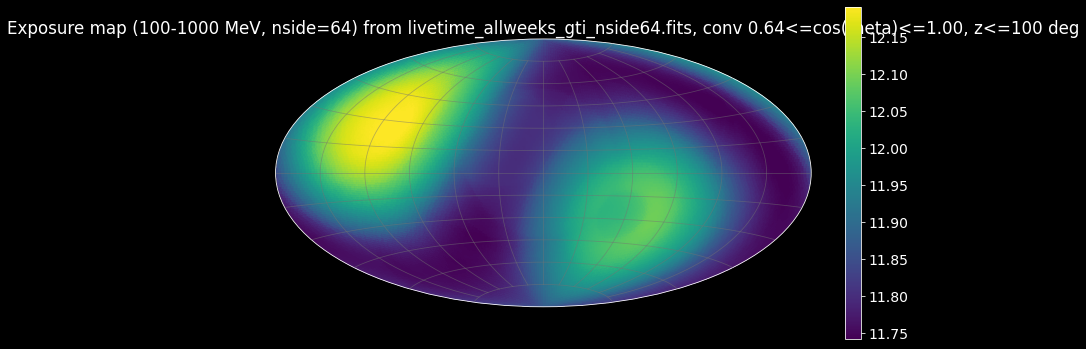

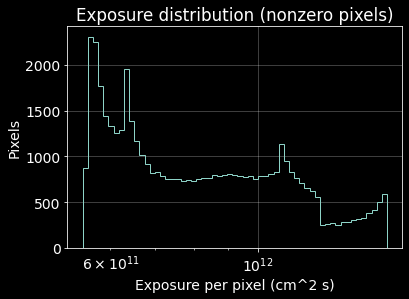

livetime source: files/livetime_allweeks_gti_nside64.fits
week tag=930, nside=64, npix=49152
cos(theta) integration range: [0.64, 1.00]
zenith cut: z <= 100.0 deg
zenith map from spacecraft history: max_weeks=8
total exposure sum: 4.190e+16 cm^2 s
nonzero pixels: 49,152
saved: files/exposure_from_saved_livetime_100_1000MeV_nside64.fits


In [50]:
# Create and display an exposure map on a HEALPix grid,
# using the saved livetime map as test input.
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from utilities.skymaps import AITfigure

from wtlike.config import Config
from wtlike.data_man import get_week_files
from wtlike.effective_area import EffectiveArea

cfg = Config()
A = EffectiveArea(file_path=cfg.datapath / 'aeff_files')

# Use the most recent available week tag for naming/output context only.
week_files = get_week_files(cfg)
week_demo = int(week_files[-1].name[-7:-4])

nside_exp = 64
emin_exp, emax_exp = 100.0, 1000.0
ctmin_exp, ctmax_exp = 0.64, 1.0
zmax_exp = 100.0

# Load previously saved livetime map.
livetime_path = Path(f'files/livetime_allweeks_gti_nside{nside_exp}.fits')
if not livetime_path.exists():
    raise FileNotFoundError(f'Could not find {livetime_path}')
lt_map = read_livetime_map(livetime_path, dtype=np.float32)

# Build a zenith-angle map from spacecraft zenith history.
# Use max_weeks_zenith=None to include all weeks (slower).
max_weeks_zenith = 8
zenith_deg_map = zenith_angle_map_from_sc(
    nside=nside_exp,
    config=cfg,
    frame='galactic',
    max_weeks=max_weeks_zenith,
)

# Exposure as spherical convolution: effective-area kernel * livetime map.
# Keep this call aligned to like3.exposure defaults unless explicitly studying sensitivity.
exp_map = make_exposure_map_healpix(
    Aeff=A,
    emin=emin_exp,
    emax=emax_exp,
    livetime=lt_map,
    ctmin=ctmin_exp,
    ctmax=ctmax_exp,
    zenith_deg=zenith_deg_map,
    zmax_deg=zmax_exp,
)

# Display map and distribution with AITfigure using log10 exposure.
plot_exp = np.full_like(exp_map, np.nan, dtype=np.float32)
pos = exp_map > 0
plot_exp[pos] = np.log10(exp_map[pos])

with plt.style.context('dark_background'):
    fig = AITfigure(figsize=(12, 6), grid_color='0.45')
    fig.healpix_fill(
        plot_exp,
        pixelsize=1.0,
        colorbar=True,
        cb_kw={'label': 'log10 exposure (cm^2 s)'},
        cmap='viridis',
        vmin=float(np.nanpercentile(plot_exp, 1)),
        vmax=float(np.nanpercentile(plot_exp, 99.5)),
    )
    fig.title(
        f'Exposure map ({emin_exp:.0f}-{emax_exp:.0f} MeV, nside={nside_exp}) '
        f'from {livetime_path.name}, conv {ctmin_exp:.2f}<=cos(theta)<={ctmax_exp:.2f}, z<={zmax_exp:.0f} deg'
     )
    fig.show()

    vals = exp_map[exp_map > 0]
    plt.figure(figsize=(6, 4))
    plt.hist(vals, bins=np.logspace(np.log10(vals.min()), np.log10(vals.max()), 60), histtype='step')
    plt.xscale('log')
    plt.xlabel('Exposure per pixel (cm^2 s)')
    plt.ylabel('Pixels')
    plt.title('Exposure distribution (nonzero pixels)')
    plt.grid(alpha=0.3)
    plt.show()

print(f'livetime source: {livetime_path}')
print(f'week tag={week_demo}, nside={nside_exp}, npix={exp_map.size}')
print(f'cos(theta) integration range: [{ctmin_exp:.2f}, {ctmax_exp:.2f}]')
print(f'zenith cut: z <= {zmax_exp:.1f} deg')
print(f'zenith map from spacecraft history: max_weeks={max_weeks_zenith}')
print(f'total exposure sum: {exp_map.sum():,.3e} cm^2 s')
print(f'nonzero pixels: {(exp_map > 0).sum():,}')

# Optional save:
out = Path(f'files/exposure_from_saved_livetime_{int(emin_exp)}_{int(emax_exp)}MeV_nside{nside_exp}.fits')
write_healpix_map(out, exp_map.astype(np.float32), overwrite=True, coord='G')
print(f'saved: {out}')

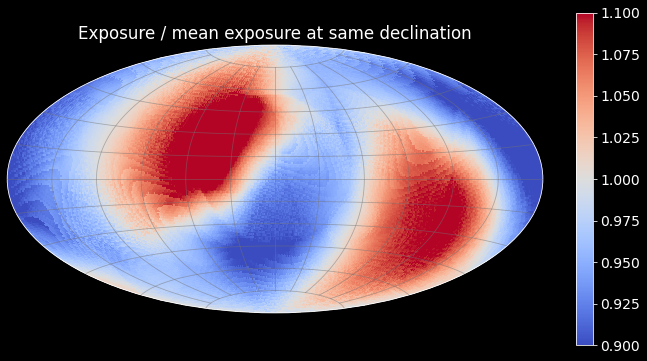

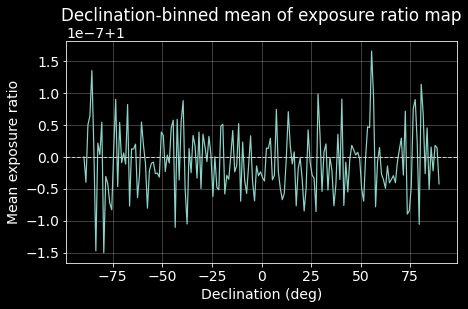

nside=64, npix=49152
ratio-map valid pixels: 49,152
global mean ratio over valid pixels: 1.0000


In [46]:
# Plot exposure ratio relative to the mean at each pixel's declination.
import astropy.units as u
from astropy.coordinates import Galactic, SkyCoord
from astropy_healpix import HEALPix, npix_to_nside
import matplotlib.pyplot as plt
import numpy as np
from utilities.skymaps import AITfigure

if 'exp_map' not in globals():
    raise RuntimeError('Run Cell 8 first to compute exp_map.')

npix = exp_map.size
nside_ratio = int(npix_to_nside(npix))
pix = np.arange(npix)

# Pixel centers are in the map frame (Galactic); convert to FK5 declination.
hpix_ratio = HEALPix(nside=nside_ratio, order='ring', frame=Galactic())
lon_gal, lat_gal = hpix_ratio.healpix_to_lonlat(pix)
dec_deg = SkyCoord(l=lon_gal, b=lat_gal, frame='galactic').fk5.dec.deg

# Mean exposure as a function of declination (1-degree bins).
dec_edges = np.linspace(-90.0, 90.0, 181)
dec_idx = np.digitize(dec_deg, dec_edges) - 1
nbin = dec_edges.size - 1

valid = (exp_map > 0) & np.isfinite(exp_map) & (dec_idx >= 0) & (dec_idx < nbin)
mean_exp_by_dec = np.full(nbin, np.nan, dtype=np.float64)

for i in range(nbin):
    m = valid & (dec_idx == i)
    if np.any(m):
        mean_exp_by_dec[i] = np.mean(exp_map[m])

ratio_map = np.full(npix, np.nan, dtype=np.float64)
ok = valid & np.isfinite(mean_exp_by_dec[dec_idx]) & (mean_exp_by_dec[dec_idx] > 0)
ratio_map[ok] = exp_map[ok] / mean_exp_by_dec[dec_idx[ok]]

with plt.style.context('dark_background'):
    # Map of exposure relative to declination-dependent mean.
    fig = AITfigure(figsize=(12, 6), grid_color='0.45')
    fig.healpix_fill(
        ratio_map,
        pixelsize=1.0,
        colorbar=True,
        cb_kw={'label': 'ratio'},
        cmap='coolwarm',
        vmin=0.9,
        vmax=1.1,
    )
    fig.title('Exposure / mean exposure at same declination')
    fig.show()

    # Sanity profile: ratio should average to ~1 in each declination bin.
    dec_centers = 0.5 * (dec_edges[:-1] + dec_edges[1:])
    profile = np.full(nbin, np.nan, dtype=np.float64)
    for i in range(nbin):
        m = ok & (dec_idx == i)
        if np.any(m):
            profile[i] = np.mean(ratio_map[m])

    plt.figure(figsize=(7, 4))
    plt.plot(dec_centers, profile, lw=1.2)
    plt.axhline(1.0, color='0.8', ls='--', lw=1)
    plt.xlabel('Declination (deg)')
    plt.ylabel('Mean exposure ratio')
    plt.title('Declination-binned mean of exposure ratio map')
    plt.grid(alpha=0.3)
    plt.show()

print(f'nside={nside_ratio}, npix={npix}')
print(f'ratio-map valid pixels: {np.sum(ok):,}')
print(f'global mean ratio over valid pixels: {np.mean(ratio_map[ok]):.4f}')